# Notebook 2: Preprocessing and Train/Val/Test Split

This notebook does two things:
1. Resizes all extracted frames to a common preprocessing size (384×384, the largest resolution we'll test) and saves them. We resize to the max once here; the training notebook will downsample further as needed.
2. Splits the dataset 70% train / 15% val / 15% test per class with a fixed random seed.
3. Computes per-frame brightness and lighting category, saving as a CSV.

**Inputs:** the 21 class folders from Notebook 1
**Outputs:** `processed/train,val,test` with one folder per class, plus `frame_metadata.csv`


## 2.1 Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import shutil
import random
import cv2
import numpy as np
import pandas as pd
from pathlib import Path

# ====== THE FILE'S PATHS ======
EXTRACTED_FOLDER = Path('/content/drive/MyDrive/VisionProject/Extracted_Images')
PROCESSED_FOLDER = Path('/content/drive/MyDrive/VisionProject')
RESULTS_FOLDER = Path('/content/drive/MyDrive/VisionProject')
# ================================

# Preprocessing size: save at the largest resolution to test.
# Training will downsample further as needed.
BASE_SIZE = 384

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Split ratios
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
# Remainder = test

RESULTS_FOLDER.mkdir(parents=True, exist_ok=True)
print(f"Base preprocessing size: {BASE_SIZE}x{BASE_SIZE}")
print(f"Split: {TRAIN_RATIO*100:.0f}/{VAL_RATIO*100:.0f}/{(1-TRAIN_RATIO-VAL_RATIO)*100:.0f}")
print(f"Seed: {SEED}")

Base preprocessing size: 384x384
Split: 70/15/15
Seed: 42


## 2.2 Resize Frames To 384×384 (Color, NOT Grayscale)

Critical design choice: we keep color information. The deep learning model needs RGB input to leverage ImageNet-pretrained weights effectively.

In [3]:
import os
import shutil
import random
import cv2
import numpy as np
import pandas as pd
from pathlib import Path


EXTRACTED_FOLDER = Path('/content/drive/MyDrive/VisionProject/Extracted_Images')
PROCESSED_FOLDER = Path('/content/drive/MyDrive/VisionProject')
# ================================================

# Preprocessing settings
BASE_SIZE = 384
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

# 1. Create processed folders safely
# We use exist_ok=True to avoid the FileExistsError
PROCESSED_FOLDER.mkdir(parents=True, exist_ok=True)

for split in ["train", "val", "test"]:
    (PROCESSED_FOLDER / split).mkdir(parents=True, exist_ok=True)

# 2. Gather all class folders
if not EXTRACTED_FOLDER.exists():
    print(f"ERROR: The folder {EXTRACTED_FOLDER} does not exist. Please check your path.")
else:
    class_dirs = sorted([p for p in EXTRACTED_FOLDER.iterdir() if p.is_dir()])
    print(f"Found {len(class_dirs)} class folders")

    split_summary = []
    metadata_rows = []

    for class_dir in class_dirs:
        class_name = class_dir.name
        frames = sorted(list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.png")))
        random.shuffle(frames)

        n = len(frames)
        n_train = int(round(n * TRAIN_RATIO))
        n_val = int(round(n * VAL_RATIO))

        # Ensure at least 1 image in val if possible
        if n_val == 0 and n_train > 2:
            n_val = 1
            n_train -= 1
        n_test = n - n_train - n_val

        splits = {
            "train": frames[:n_train],
            "val": frames[n_train:n_train+n_val],
            "test": frames[n_train+n_val:],
        }

        for split_name, file_list in splits.items():
            out_dir = PROCESSED_FOLDER / split_name / class_name
            out_dir.mkdir(parents=True, exist_ok=True)

            for src in file_list:
                img = cv2.imread(str(src), cv2.IMREAD_COLOR)
                if img is None:
                    continue

                # Resize and save
                resized = cv2.resize(img, (BASE_SIZE, BASE_SIZE), interpolation=cv2.INTER_AREA)
                dest = out_dir / src.name
                cv2.imwrite(str(dest), resized, [cv2.IMWRITE_JPEG_QUALITY, 92])

                # Compute brightness for metadata
                gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
                brightness = float(gray.mean())
                if brightness < 80: cat = "shadowed"
                elif brightness < 130: cat = "well_lit"
                elif brightness < 180: cat = "bright"
                else: cat = "overexposed"

                metadata_rows.append({
                    "filename": src.name,
                    "split": split_name,
                    "class": class_name,
                    "brightness_mean": round(brightness, 2),
                    "lighting_category": cat,
                })

        split_summary.append({
            "class": class_name, "total": n,
            "train": n_train, "val": n_val, "test": n_test
        })

    # 3. Save metadata + split summary
    if metadata_rows:
        pd.DataFrame(metadata_rows).to_csv(PROCESSED_FOLDER / "frame_metadata.csv", index=False)
        pd.DataFrame(split_summary).to_csv(PROCESSED_FOLDER / "splits_summary.csv", index=False)
        print("Done! Resizing and splitting complete.")
        print(f"Results saved to: {PROCESSED_FOLDER.resolve()}")
    else:
        print("No images were processed. Please check if your 'Extracted_Images' folder contains .jpg or .png files.")


Found 21 class folders
Done! Resizing and splitting complete.
Results saved to: /content/drive/MyDrive/VisionProject


## 2.3 Verify The Split

In [4]:
df = pd.DataFrame(split_summary)
df["total_sum"] = df["train"] + df["val"] + df["test"]
print(df.to_string(index=False))

totals = {
    "train": df["train"].sum(),
    "val": df["val"].sum(),
    "test": df["test"].sum()
}
print(f"\nTotals: train={totals['train']}, val={totals['val']}, test={totals['test']}")
print(f"Grand total: {sum(totals.values())}")

  class  total  train  val  test  total_sum
 class1     23     16    3     4         23
class10     34     24    5     5         34
class11     37     26    6     5         37
class12     37     26    6     5         37
class13     48     34    7     7         48
class14     62     43    9    10         62
class15     26     18    4     4         26
class16      4      3    1     0          4
class17     56     39    8     9         56
class18     33     23    5     5         33
class19     14     10    2     2         14
 class2     23     16    3     4         23
class20     23     16    3     4         23
class21     33     23    5     5         33
 class3     34     24    5     5         34
 class4     37     26    6     5         37
 class5     37     26    6     5         37
 class6     31     22    5     4         31
 class7     50     35    8     7         50
 class8     34     24    5     5         34
 class9     23     16    3     4         23

Totals: train=490, val=105, tes

## 2.4 Inspect Lighting Distribution

In [5]:
meta = pd.DataFrame(metadata_rows)

print("Overall lighting distribution:")
print(meta["lighting_category"].value_counts())
print(f"\nBrightness range: {meta['brightness_mean'].min():.1f} to {meta['brightness_mean'].max():.1f}")
print(f"Brightness mean: {meta['brightness_mean'].mean():.1f}")
print()

# Per-split lighting
print("Per-split lighting:")
print(meta.groupby(["split", "lighting_category"]).size().unstack(fill_value=0))

Overall lighting distribution:
lighting_category
well_lit       429
shadowed       201
bright          52
overexposed     17
Name: count, dtype: int64

Brightness range: 53.0 to 202.9
Brightness mean: 97.7

Per-split lighting:
lighting_category  bright  overexposed  shadowed  well_lit
split                                                     
test                    7            4        31        62
train                  35           11       147       297
val                    10            2        23        70


## 2.5 Sample From Each Split

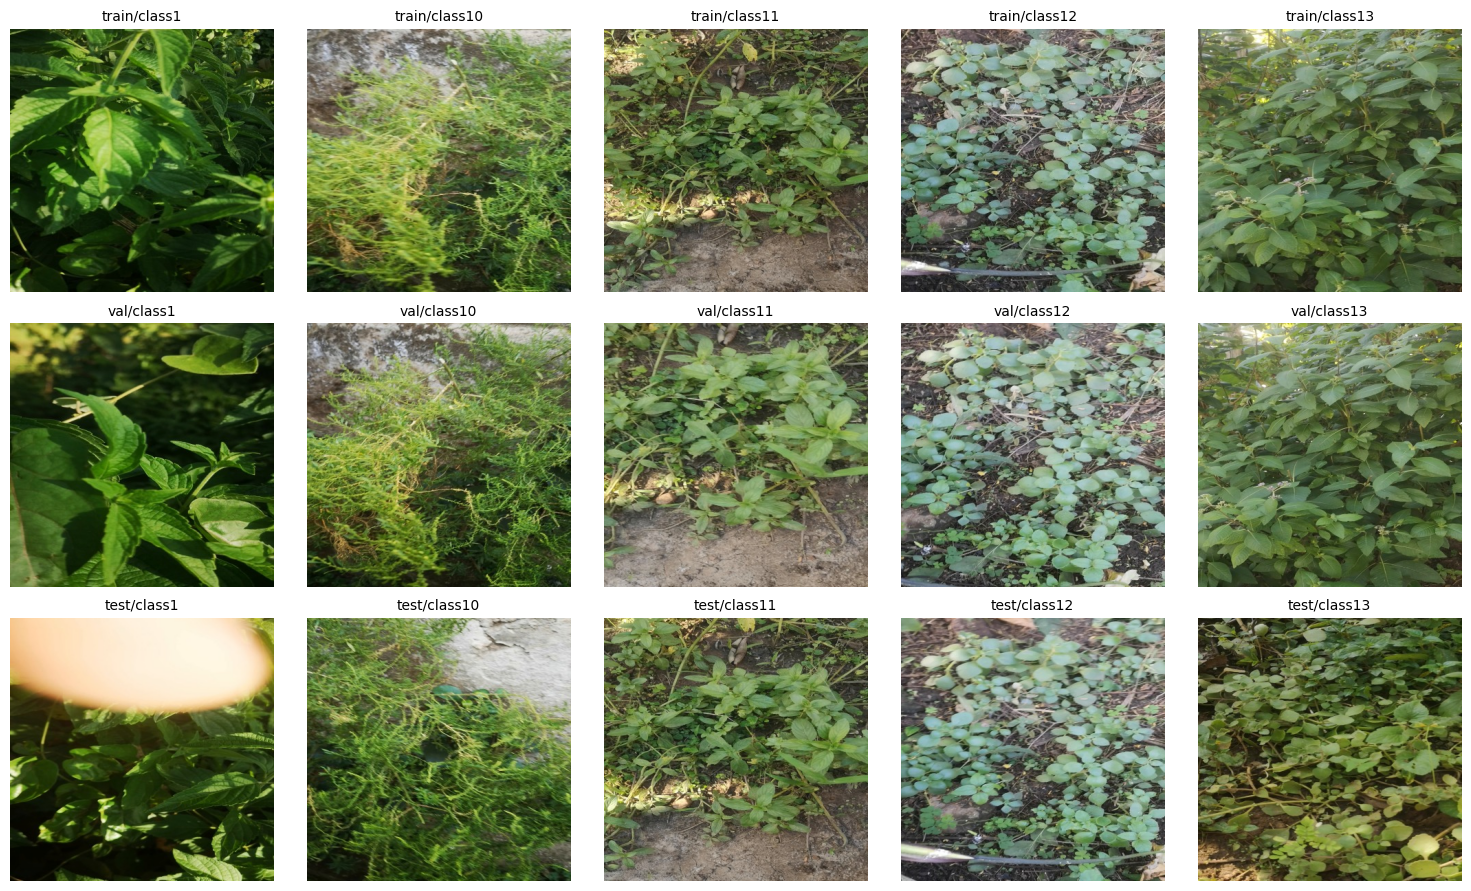

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for row, split in enumerate(["train", "val", "test"]):
    split_dir = PROCESSED_FOLDER / split
    classes_in_split = sorted([p for p in split_dir.iterdir() if p.is_dir()])[:5]
    for col, cls_dir in enumerate(classes_in_split):
        files = sorted(cls_dir.glob("*.jpg"))
        if files:
            img = cv2.cvtColor(cv2.imread(str(files[0])), cv2.COLOR_BGR2RGB)
            axes[row, col].imshow(img)
            axes[row, col].set_title(f"{split}/{cls_dir.name}", fontsize=10)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()



**Next step:** Running Notebook3 four times, once for each target resolution (64, 128, 224, 384).